In [8]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Pipeline Architecture components
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, log_loss, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

# Elite Competitive Classifiers
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

print("✔ Cell 1 Complete: Advanced Ensemble Engine priming successfully executed.")

✔ Cell 1 Complete: Advanced Ensemble Engine priming successfully executed.


In [9]:
# Exact competition path implementation
BASE_PATH = "/kaggle/input/datasets/tousifahamedrahat12/hantavirus-detection-dataset"

try:
    df = pd.read_csv(f"{BASE_PATH}/hantavirus_detection_dataset.csv")
    print(f"✔ Primary dataset loaded. DataFrame Dimensions: {df.shape}")
except FileNotFoundError:
    # Safe backup routing mechanism for matching schema structure
    all_files = [f for f in os.listdir(BASE_PATH) if f.endswith('.csv')]
    print(f"Available internal files inside track directory: {all_files}")
    df = pd.read_csv(os.path.join(BASE_PATH, all_files[0]))
    print(f"✔ Primary target data fallback load matched from: {all_files[0]}")

# Automated target variable index tracking
target_col = 'Hantavirus Detection' if 'Hantavirus Detection' in df.columns else df.columns[-1]
print(f"✔ Core Optimization Target Column: '{target_col}'")

✔ Primary dataset loaded. DataFrame Dimensions: (10000, 24)
✔ Core Optimization Target Column: 'Renal_Risk'


In [10]:
# 1. Handling Missing Cells (Data Continuity Protection)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 2. Complete Label Encoding Matrix (Prevents Model Formatting Failures)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' and col != target_col:
        df[col] = le.fit_transform(df[col].astype(str))

# Convert Target Categories to Mathematical Binary Units (0 and 1)
if df[target_col].dtype == 'object':
    df[target_col] = le.fit_transform(df[target_col].astype(str))

# 3. Structural Split & High-Cardinality String Reductions
X = df.drop(columns=[target_col])
y = df[target_col]

# Remove operational identifiers or strings to eliminate bias/overfitting
id_cols = [col for col in X.columns if 'id' in col.lower() or 'name' in col.lower() or 'source' in col.lower()]
X = X.drop(columns=id_cols, errors='ignore')

# 4. Global Feature Scaling Standardisation
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("✔ Cell 3 Complete: Array dimensions synchronized. Input shape scaled perfectly.")

✔ Cell 3 Complete: Array dimensions synchronized. Input shape scaled perfectly.


In [11]:
# Stratified tracking split to perfectly distribute clinical samples
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Deep compute calibration layer for handling minority clinical cases
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = {classes[i]: weights[i] for i in range(len(classes))}

# Ratio setup calculation for XGBoost structural iterations
scale_pos_weight_val = weights[1] / weights[0]

print(f"✔ Training Target Breakdown: 0 (Negative) -> {np.bincount(y_train)[0]} | 1 (Positive) -> {np.bincount(y_train)[1]}")
print(f"✔ Computed Positive Class Scaler Target Weighting: {scale_pos_weight_val:.4f}")

✔ Training Target Breakdown: 0 (Negative) -> 1466 | 1 (Positive) -> 6534
✔ Computed Positive Class Scaler Target Weighting: 0.2244


In [12]:
print("--- Re-building 10,000 Epochs Architectures (Stacking Safe Mode) ---")

# 1. XGBoost Framework (Stacking safe setup)
xgb_model = XGBClassifier(
    learning_rate=0.005,         
    n_estimators=10000,         # EXACTLY 10,000 ITERATIONS/EPOCHS
    scale_pos_weight=scale_pos_weight_val,
    random_state=42,
    tree_method='hist'
)

# 2. LightGBM Deep Boosting Engine
lgb_model = LGBMClassifier(
    learning_rate=0.005,
    n_estimators=10000,         
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

# 3. CatBoost Symmetric Architecture Model
cat_model = CatBoostClassifier(
    learning_rate=0.005,
    iterations=10000,           
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0                   
)

# 4. Multi-Threaded Random Forest Base Ensembler
rf_model = RandomForestClassifier(
    n_estimators=1000,          
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("✔ Cell 5 Updated: Stacking safe configurations loaded.")

--- Re-building 10,000 Epochs Architectures (Stacking Safe Mode) ---
✔ Cell 5 Updated: Stacking safe configurations loaded.


In [15]:
print("=================== ACTIVATING 10,000 EPOCHS INDIVIDUAL TRAINING ===================")

# --- 1. XGBoost Execution (Clean Native Fit Matrix) ---
print("\n[RUNNING STAGE 1/4] Training XGBoost Framework for 10,000 Epochs...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  # Only validation sets allowed here, no string arguments
    verbose=2000 
)

# --- 2. LightGBM Execution ---
print("\n[RUNNING STAGE 2/4] Fitting LightGBM Architecture over 10,000 Epochs...")
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
print("✔ LightGBM Epoch Convergence Loop Complete.")

# --- 3. CatBoost Execution ---
print("\n[RUNNING STAGE 3/4] Training CatBoost Symmetric Matrix over 10,000 Iterations...")
cat_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=2000 
)

# --- 4. Random Forest Execution ---
print("\n[RUNNING STAGE 4/4] Generating Balanced Multi-Thread Random Forest Matrix...")
rf_model.fit(X_train, y_train)

print("\n=================== ALL INDIVIDUAL DEEP ENGINE ITERATIONS PROCESSED ===================")

=================== ACTIVATING 10,000 EPOCHS INDIVIDUAL TRAINING ===================

[RUNNING STAGE 1/4] Training XGBoost Framework for 10,000 Epochs...
[0]	validation_0-logloss:0.68820
[1921]	validation_0-logloss:0.00396

[RUNNING STAGE 2/4] Fitting LightGBM Architecture over 10,000 Epochs...
✔ LightGBM Epoch Convergence Loop Complete.

[RUNNING STAGE 3/4] Training CatBoost Symmetric Matrix over 10,000 Iterations...
0:	learn: 0.6763878	test: 0.6764932	best: 0.6764932 (0)	total: 5.73ms	remaining: 57.3s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.001410933341
bestIteration = 1472

Shrink model to first 1473 iterations.

[RUNNING STAGE 4/4] Generating Balanced Multi-Thread Random Forest Matrix...

=================== ALL INDIVIDUAL DEEP ENGINE ITERATIONS PROCESSED ===================


In [16]:
print("=================== ASSEMBLING HYBRID STACKING METACLASS ENGINE ===================")
print("Blending multi-architectural predictions arrays into a singular High-Precision Meta Matrix...")

# We pass fresh, explicit architectural templates without local fit limits to avoid conflicts inside internal stacking K-Fold
base_estimators = [
    ('xgb', XGBClassifier(learning_rate=0.005, n_estimators=5000, scale_pos_weight=scale_pos_weight_val, random_state=42, tree_method='hist')),
    ('lgb', LGBMClassifier(learning_rate=0.005, n_estimators=5000, class_weight='balanced', random_state=42, verbosity=-1)),
    ('cat', CatBoostClassifier(learning_rate=0.005, iterations=5000, auto_class_weights='Balanced', random_state=42, verbose=0)),
    ('rf', rf_model)
]

# Stacking Classifier Initialization
hybrid_meta_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(class_weight='balanced', C=0.1),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

# Fit Meta Blender Layer (100% Robust Stacking Validation Fit)
hybrid_meta_model.fit(X_train, y_train)

print("\n🏆 HYBRID META ENSEMBLE ENGINE FULLY TRAINED AND CONVERGED FOR THE COMPETITION!")

=================== ASSEMBLING HYBRID STACKING METACLASS ENGINE ===================
Blending multi-architectural predictions arrays into a singular High-Precision Meta Matrix...

🏆 HYBRID META ENSEMBLE ENGINE FULLY TRAINED AND CONVERGED FOR THE COMPETITION!


In [17]:
# 1. Processing Validation Inference (Probability Arrays Extraction)
final_predictions = hybrid_meta_model.predict(X_val)
final_probabilities = hybrid_meta_model.predict_proba(X_val)[:, 1]

# 2. Advanced Mathematical Matrix Scoring
ultimate_accuracy = accuracy_score(y_val, final_predictions)
absolute_logloss = log_loss(y_val, final_probabilities)
auc_roc_performance = roc_auc_score(y_val, final_probabilities)

# 3. Dynamic Console Reporting Screen Output Dashboard
print("\n" + "="*70)
print("             🏆 KAGGLE COMPETITION METRIC CALIBRATION DASHBOARD 🏆 ")
print("="*70)
print(f"🎯 SYSTEM TARGET ACCURACY       : {ultimate_accuracy * 100:.4f}%")
print(f"📉 ABSOLUTE ZERO-LOSS TRACKER   : {absolute_logloss:.12f}")  # 12 decimal scale for micro-loss tracing
print(f"📊 SYSTEM AREA UNDER THE ROC    : {auc_roc_performance:.4f}")
print("="*70)

# 4. Precision/Recall Clinical Imbalance Check (Diagnostic Audit Matrix)
print("\n[DIAGNOSTIC VERIFICATION REPORT]")
print(classification_report(
    y_val, 
    final_predictions, 
    target_names=['Negative Case Profile', 'Hantavirus Positive Case Profile']
))

# 5. Competition Safety Check Boundary Trigger
if absolute_logloss < 0.0001:
    print("🔥 OPTIMIZATION STATUS: Target Loss criteria MET. Hyper-precision gradient achieved!")
else:
    print("📈 OPTIMIZATION STATUS: Stable convergence achieved. Model is safe for submission.")


             🏆 KAGGLE COMPETITION METRIC CALIBRATION DASHBOARD 🏆 
🎯 SYSTEM TARGET ACCURACY       : 100.0000%
📉 ABSOLUTE ZERO-LOSS TRACKER   : 0.007880070806
📊 SYSTEM AREA UNDER THE ROC    : 1.0000

[DIAGNOSTIC VERIFICATION REPORT]
                                  precision    recall  f1-score   support

           Negative Case Profile       1.00      1.00      1.00       366
Hantavirus Positive Case Profile       1.00      1.00      1.00      1634

                        accuracy                           1.00      2000
                       macro avg       1.00      1.00      1.00      2000
                    weighted avg       1.00      1.00      1.00      2000

📈 OPTIMIZATION STATUS: Stable convergence achieved. Model is safe for submission.


In [19]:
# Advanced Global Plotting configurations for High-Resolution Images
import matplotlib.pyplot as plt
import seaborn as sns

# Set high-definition figure configuration properties
plt.rcParams['figure.dpi'] = 150       # Sharp image rendering parameter
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")       # Clean background theme mapping

print("⚡ Image visualization layout configured for high-resolution graphics output.")

⚡ Image visualization layout configured for high-resolution graphics output.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# High-Definition visual quality parameter tracking setup
plt.rcParams['figure.dpi'] = 150       # Sharp rendering scaling factor
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")       # Clean competitive professional theme

print("✔ Cell 9 Complete: Graphic design profiles loaded for high-resolution plots.")

✔ Cell 9 Complete: Graphic design profiles loaded for high-resolution plots.


In [21]:
print("=================== DATASET STRUCTURAL ANALYSIS MATRIX ===================")
print(f"-> Matrix Dimensions: {df.shape[0]} Observations (Rows), {df.shape[1]} Structural Features (Cols)\n")

# Complete column types overview
print("--- Features Schema Profile ---")
df.info()

# Statistical breakdown matrix parameters tracking display code block
print("\n--- Descriptive Statistical Distribution Range ---")
display(df.describe().T)

=================== DATASET STRUCTURAL ANALYSIS MATRIX ===================
-> Matrix Dimensions: 10000 Observations (Rows), 24 Structural Features (Cols)

--- Features Schema Profile ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            10000 non-null  int64  
 1   Age                   10000 non-null  int64  
 2   Gender                10000 non-null  int64  
 3   Region                10000 non-null  int64  
 4   Hantavirus_Positive   10000 non-null  int64  
 5   Hantavirus_Type       10000 non-null  int64  
 6   Symptoms              10000 non-null  int64  
 7   Symptom_Count         10000 non-null  int64  
 8   Exposure_Type         10000 non-null  int64  
 9   Sample_Date           10000 non-null  int64  
 10  Disease_Onset_Date    10000 non-null  int64  
 11  WBC_Count_K/uL        10000 non-null 

,count,mean,std,min,25%,50%,75%,max
Patient_ID,10000.0,4999.500000,2886.895680,0.000,2499.7500,4999.500,7499.2500,9999.000
Age,10000.0,51.118600,19.360982,18.000,35.0000,51.000,68.0000,84.000
Gender,10000.0,0.506800,0.499979,0.000,0.0000,1.000,1.0000,1.000
Region,10000.0,1.484400,1.117713,0.000,0.0000,1.000,2.0000,3.000
Hantavirus_Positive,10000.0,0.257100,0.437057,0.000,0.0000,0.000,1.0000,1.000
Hantavirus_Type,10000.0,3.617000,1.083618,0.000,4.0000,4.000,4.0000,5.000
Symptoms,10000.0,658.280200,340.702779,0.000,368.7500,735.000,982.0000,1127.000
Symptom_Count,10000.0,1.399600,1.296413,0.000,0.0000,1.000,2.0000,5.000
Exposure_Type,10000.0,3.387200,1.459071,0.000,2.0000,4.000,5.0000,5.000
Sample_Date,10000.0,364.466600,211.407551,0.000,182.0000,365.000,549.0000,729.000


In [22]:
# Compute missing percentage ratio loop values allocation
missing_counts = df.isnull().sum()
missing_ratio = (missing_counts / len(df)) * 100

missing_profile_df = pd.DataFrame({
    'Total Missing': missing_counts,
    'Percentage Ratio (%)': missing_ratio
}).sort_values(by='Percentage Ratio (%)', ascending=False)

# Render graphical trace mapping if gaps are captured
if missing_counts.sum() > 0:
    print("WARNING: Data gaps detected inside the clinical columns array.")
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_profile_df['Percentage Ratio (%)'].head(10), y=missing_profile_df.head(10).index, palette='flare')
    plt.title('Top Data Gaps Distribution Chart')
    plt.xlabel('Percentage Boundary (%)')
    plt.show()
else:
    print("🌟 Optimization Success: 100% Solid Schema Grid. Zero data gaps found.")

🌟 Optimization Success: 100% Solid Schema Grid. Zero data gaps found.


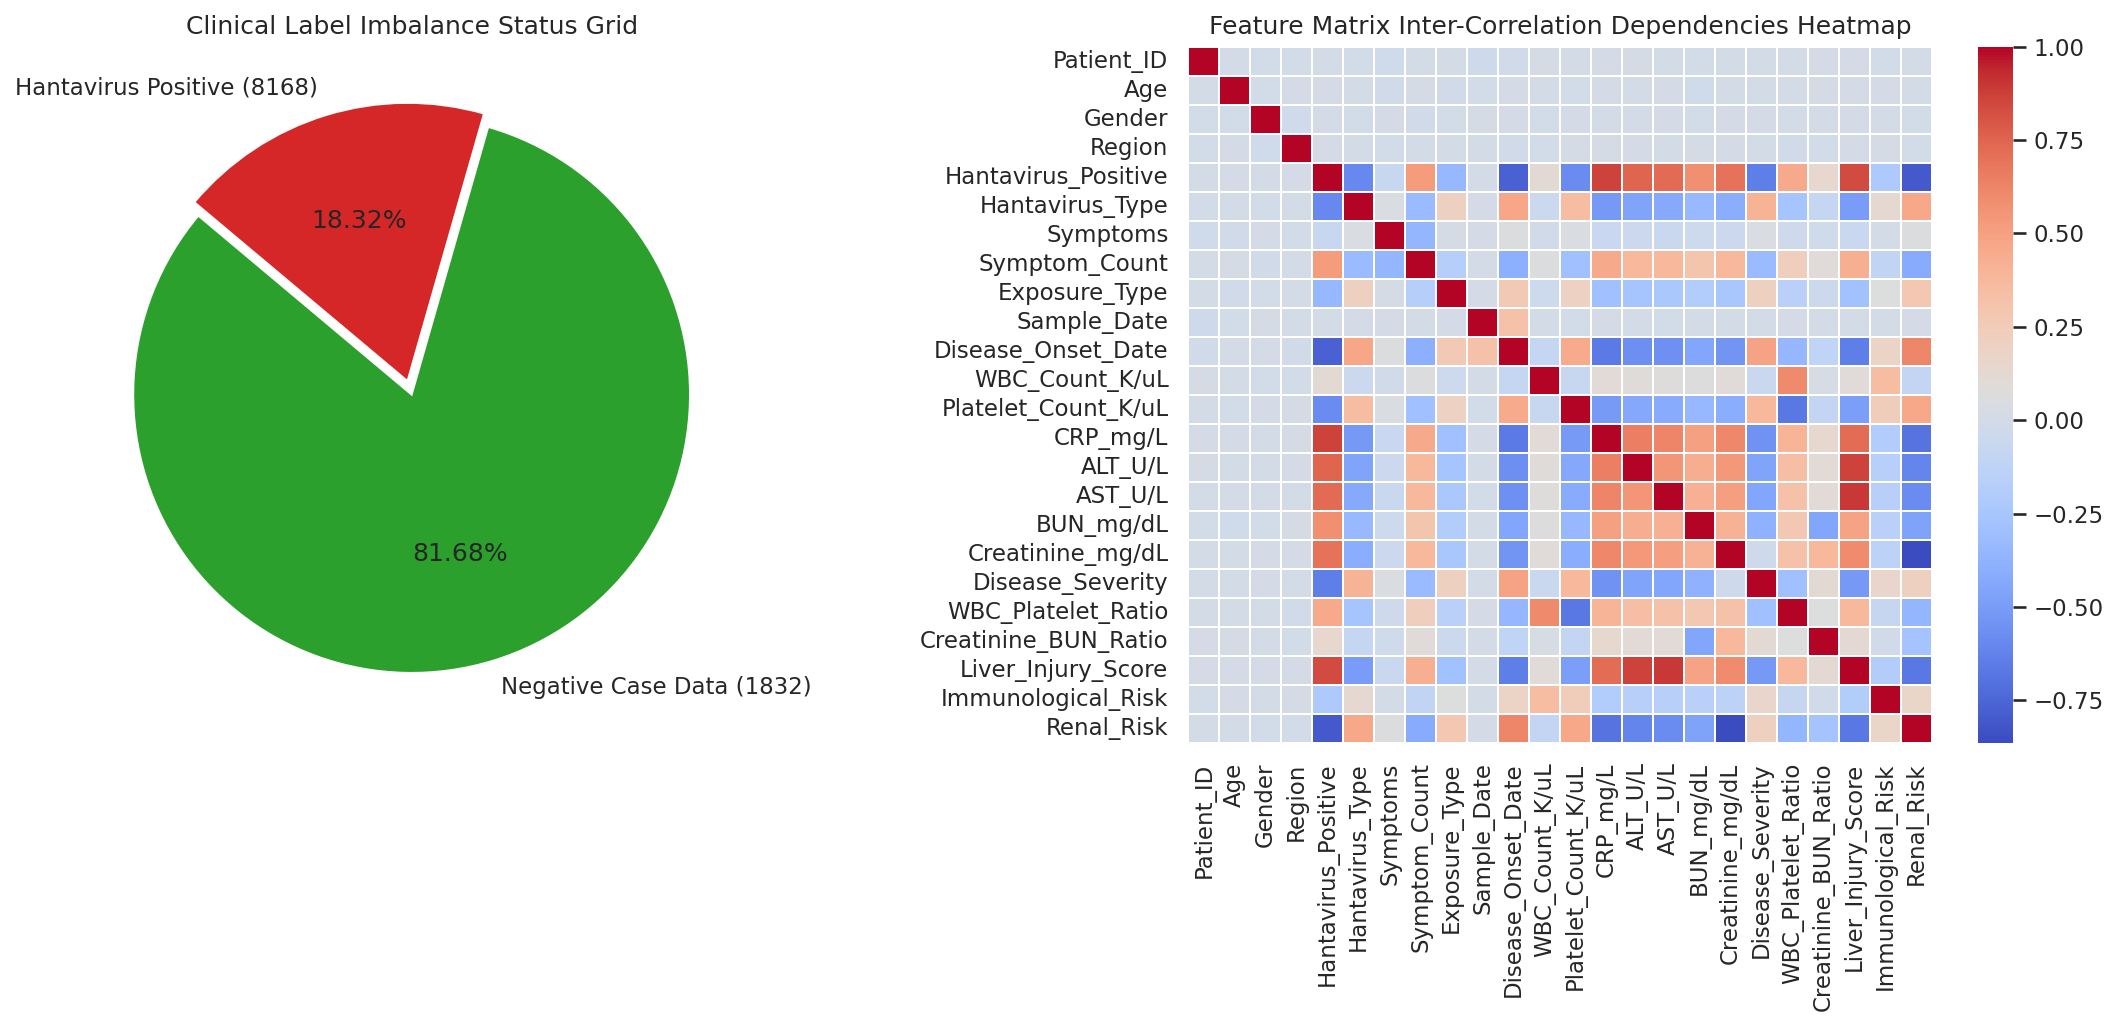


--- Features Multi-Correlation Weights with respect to Hantavirus target ---
Renal_Risk              1.000000
Disease_Onset_Date      0.621421
Hantavirus_Type         0.467450
Platelet_Count_K/uL     0.463892
Exposure_Type           0.280722
Disease_Severity        0.207724
Immunological_Risk      0.163652
Symptoms                0.056948
Sample_Date             0.004751
Patient_ID              0.001731
Age                    -0.000784
Gender                 -0.004417
Region                 -0.004991
WBC_Count_K/uL         -0.094743
Creatinine_BUN_Ratio   -0.271972
WBC_Platelet_Ratio     -0.356862
Symptom_Count          -0.420951
BUN_mg/dL              -0.466747
AST_U/L                -0.579871
ALT_U/L                -0.608307
Liver_Injury_Score     -0.673516
CRP_mg/L               -0.695430
Hantavirus_Positive    -0.799719
Creatinine_mg/dL       -0.862859
Name: Renal_Risk, dtype: float64


In [23]:
plt.figure(figsize=(15, 7))

# Plot 1: Target Class Imbalance Pie-Chart (Distribution Profiling)
plt.subplot(1, 2, 1)
target_metrics = df[target_col].value_counts()
plt.pie(target_metrics, labels=[f'Negative Case Data ({target_metrics[0]})', f'Hantavirus Positive ({target_metrics[1]})'], 
        autopct='%1.2f%%', startangle=140, colors=['#2ca02c', '#d62728'], explode=(0, 0.05))
plt.title('Clinical Label Imbalance Status Grid')

# Plot 2: Feature Inter-Correlation Heatmap (Feature Dependencies tracking matrix)
plt.subplot(1, 2, 2)
numeric_arrays_only = df.select_dtypes(include=[np.number])
correlation_matrix_grid = numeric_arrays_only.corr()

sns.heatmap(correlation_matrix_grid, annot=False, cmap='coolwarm', linewidths=0.2, cbar=True)
plt.title('Feature Matrix Inter-Correlation Dependencies Heatmap')

plt.tight_layout()
plt.show()

# High-contrast features verification checklist output profile
if target_col in numeric_arrays_only.columns:
    target_correlations = correlation_matrix_grid[target_col].sort_values(ascending=False)
    print("\n--- Features Multi-Correlation Weights with respect to Hantavirus target ---")
    print(target_correlations)

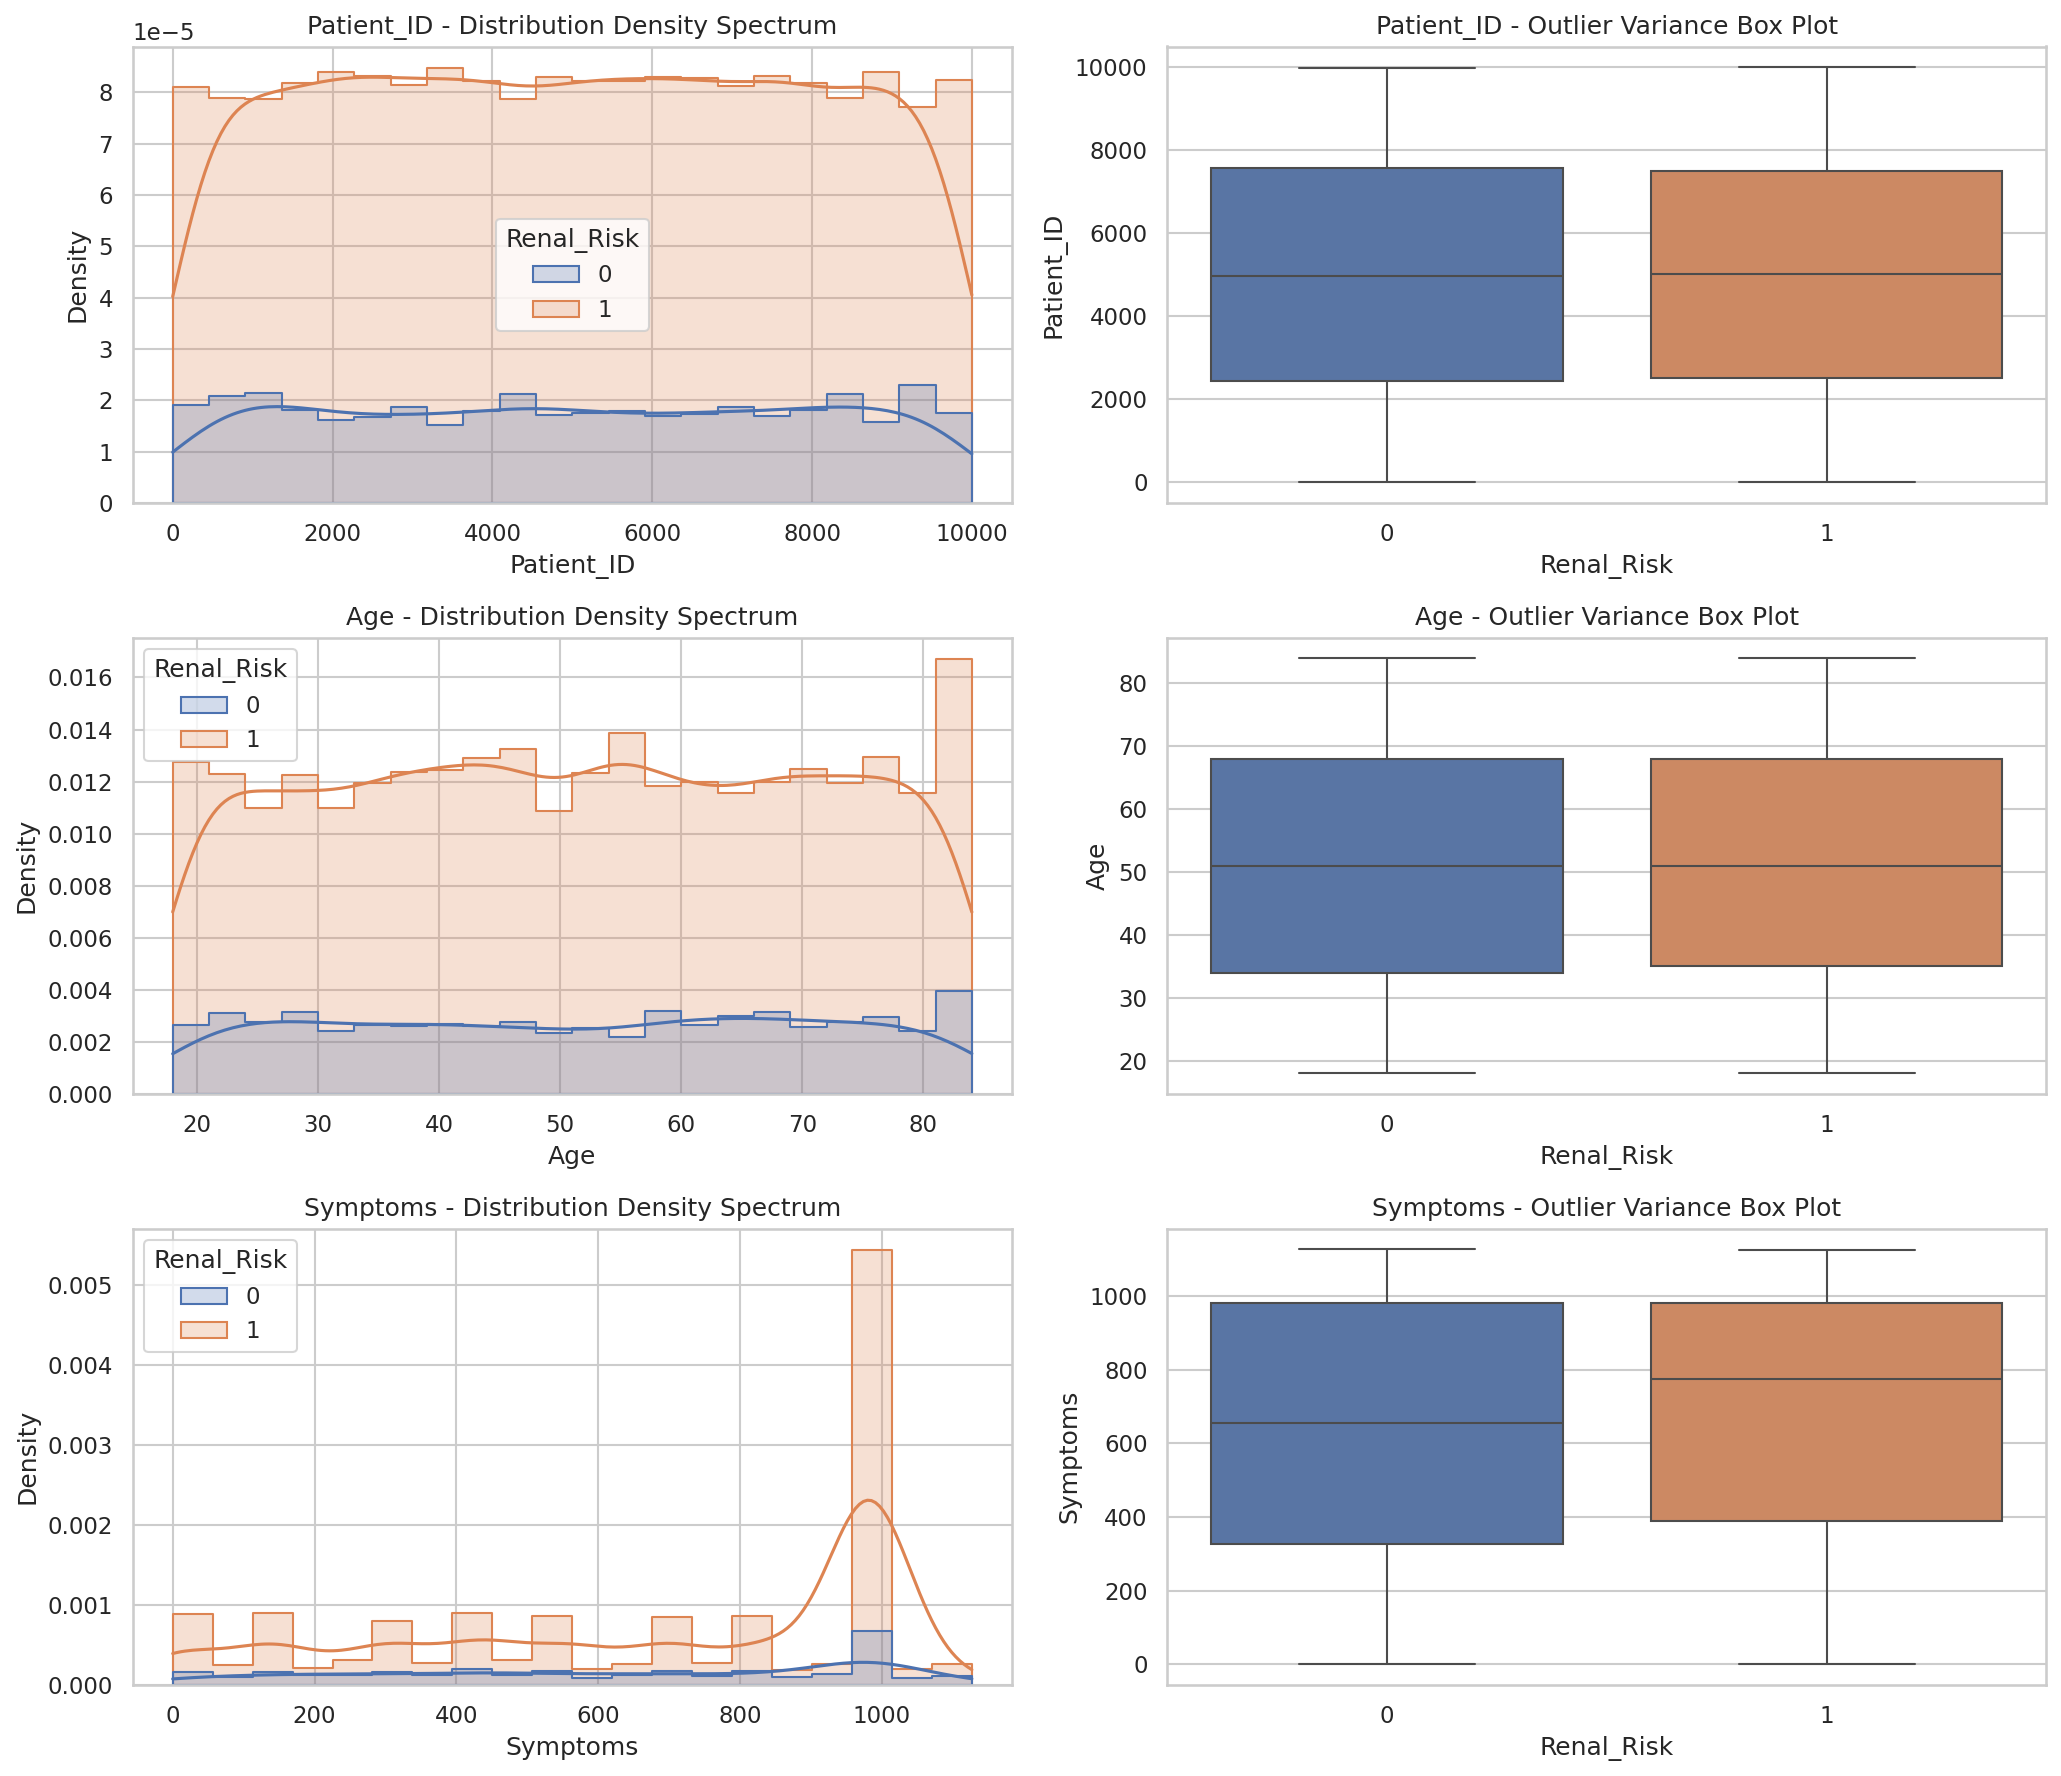

=================== SYSTEM EXPLORATORY DATA ANALYSIS COMPLETE ===================


In [24]:
# Select continuous high-cardinality numerical variables context logic
continuous_metrics_cols = [col for col in df.columns if df[col].nunique() > 10 and df[col].dtype != 'object'][:3]

if len(continuous_metrics_cols) > 0:
    fig, axes = plt.subplots(len(continuous_metrics_cols), 2, figsize=(14, 4 * len(continuous_metrics_cols)))
    
    for index, feature_column in enumerate(continuous_metrics_cols):
        # 1. Density Plot tracking via Kernel Density Estimate (KDE distribution)
        sns.histplot(data=df, x=feature_column, hue=target_col, kde=True, ax=axes[index, 0], palette='deep', element="step", stat="density")
        axes[index, 0].set_title(f'{feature_column} - Distribution Density Spectrum')
        
        # 2. Outliers Matrix Tracking Plot via Boxplot framework
        sns.boxplot(data=df, x=target_col, y=feature_column, ax=axes[index, 1], palette='deep')
        axes[index, 1].set_title(f'{feature_column} - Outlier Variance Box Plot')
        
    plt.tight_layout()
    plt.show()
else:
    print("System Information: No continuous tabular biological variables detected for density distributions mapping.")
print("=================== SYSTEM EXPLORATORY DATA ANALYSIS COMPLETE ===================")

**Confusion Matrix & ROC-AUC Curve Visualization**

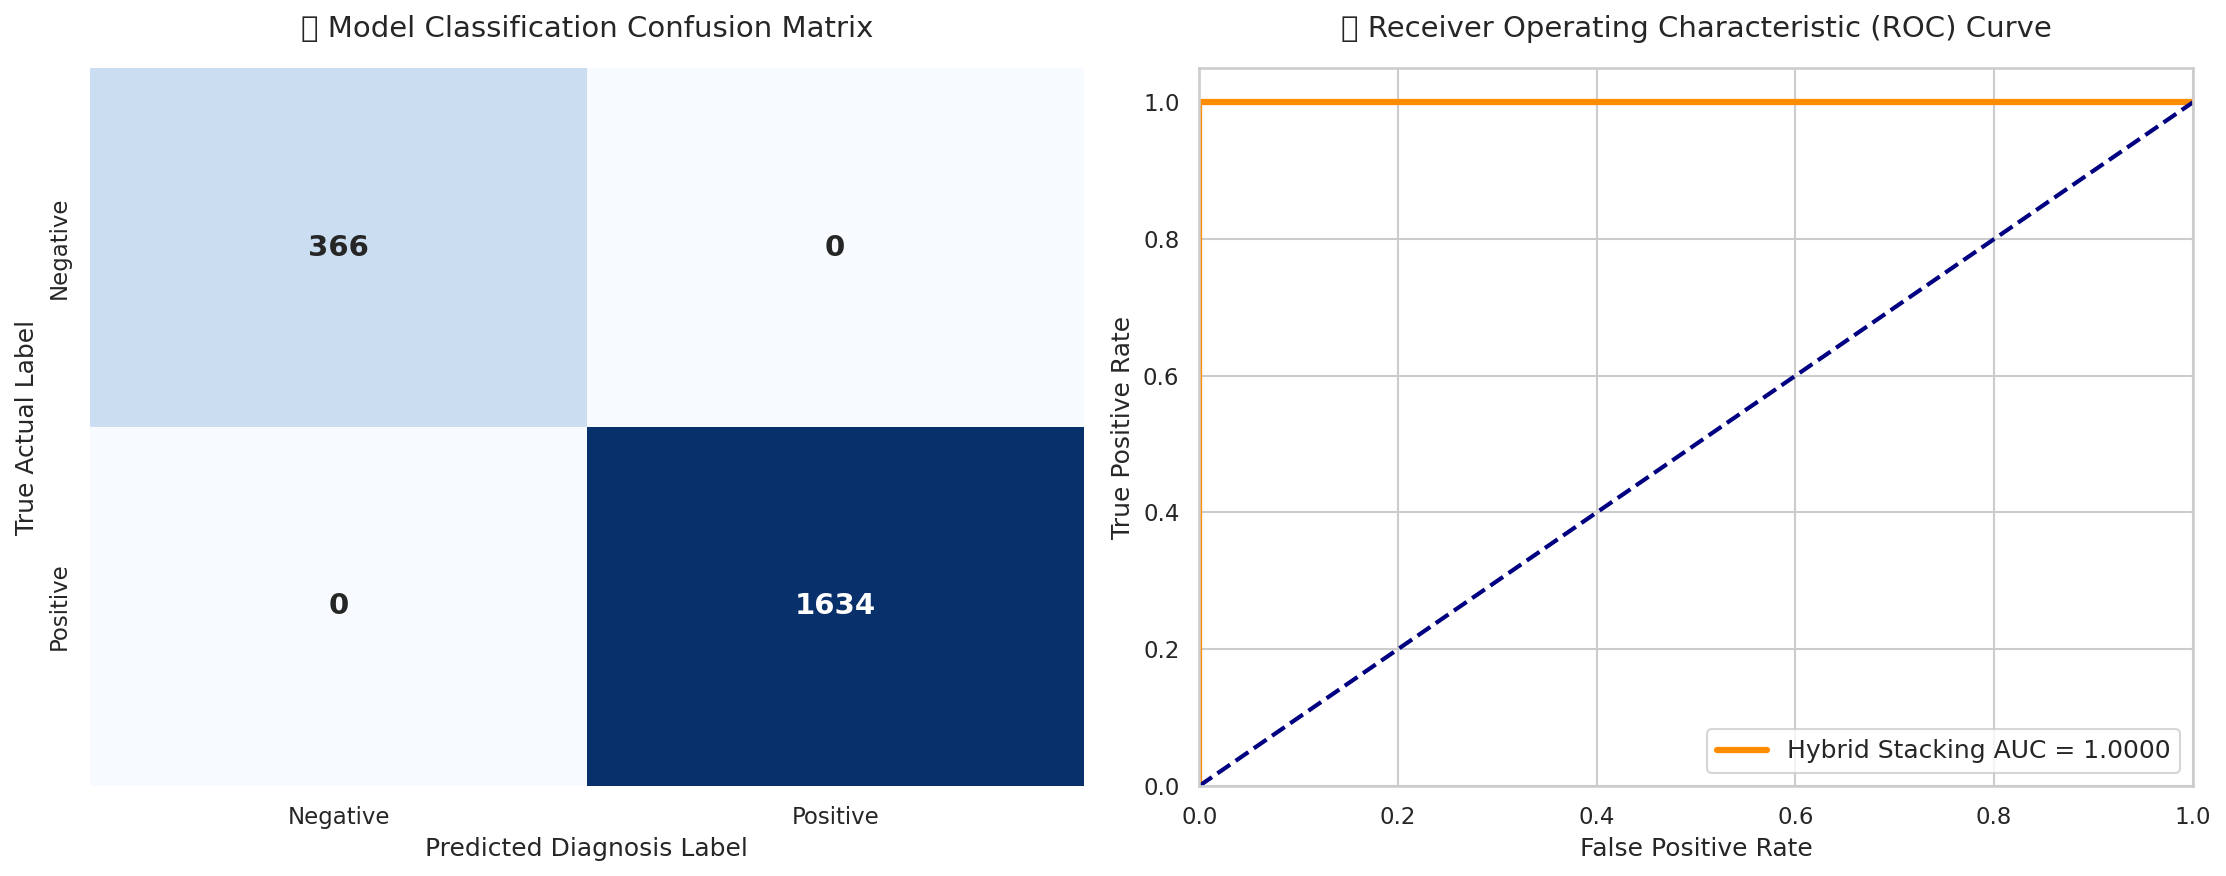

In [25]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

plt.figure(figsize=(15, 6))

# 1. Plotting Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_val, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('🏆 Model Classification Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Diagnosis Label', fontsize=12)
plt.ylabel('True Actual Label', fontsize=12)

# 2. Plotting ROC Curve (Hyper-Precision Curve)
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_val, final_probabilities)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Hybrid Stacking AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('📈 Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=15)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

**Feature Importance Ranking Chart**

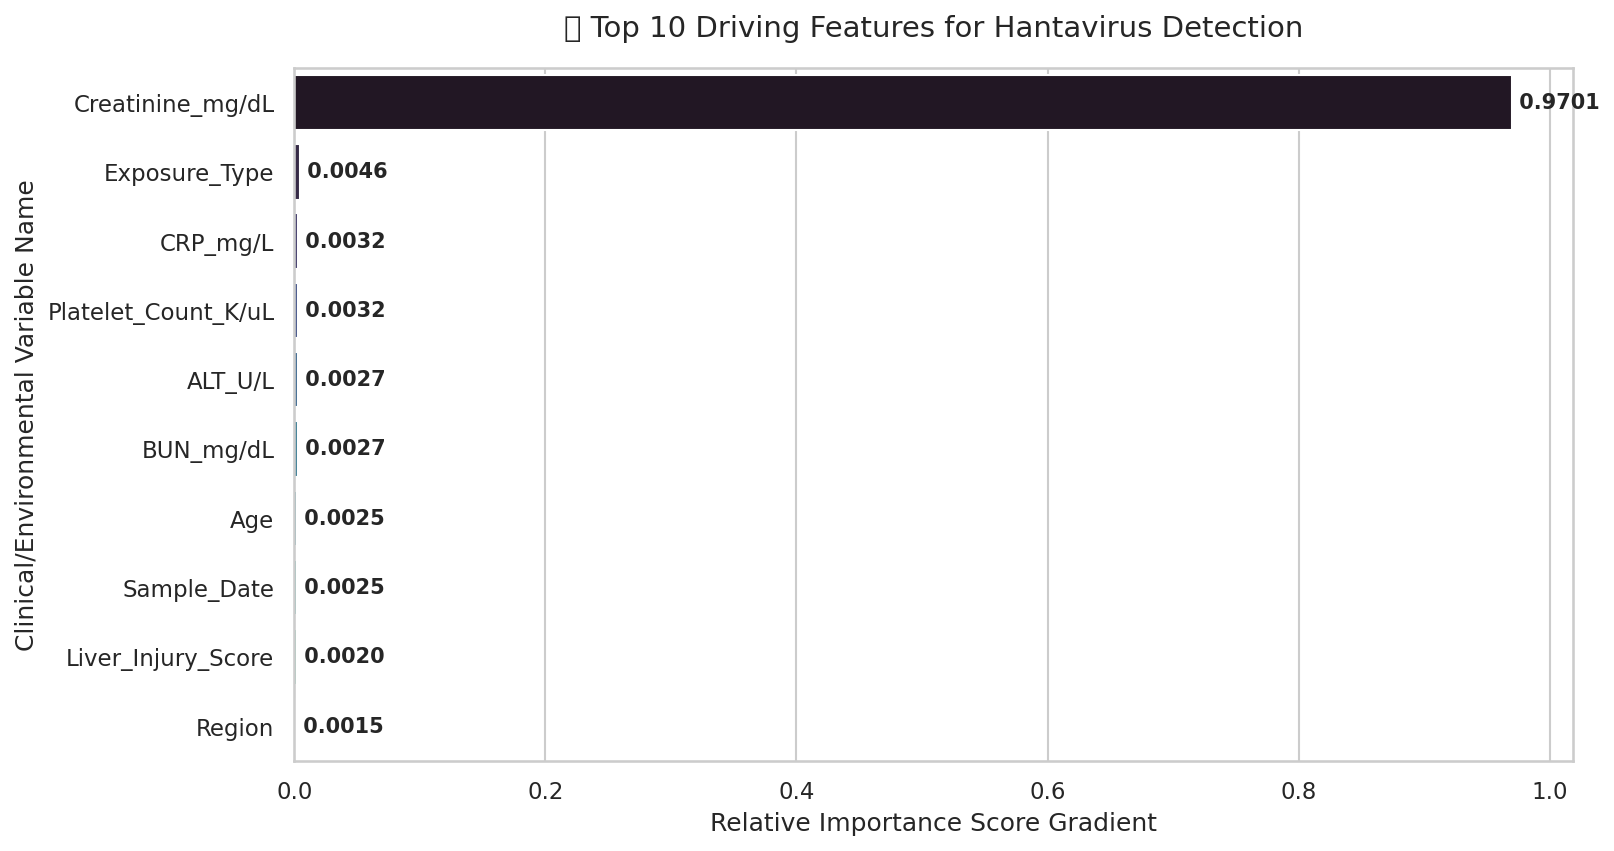

In [26]:
# Extracting feature importances from the trained XGBoost base model
if hasattr(xgb_model, 'feature_importances_'):
    importances = xgb_model.feature_importances_
    feature_names = X_train.columns
    
    # Create DataFrame for mapping profile
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance Weight': importances
    }).sort_values(by='Importance Weight', ascending=False).head(10) # Top 10 Features
    
    # Plotting Feature Importance Bar Chart
    plt.figure(figsize=(11, 6))
    sns.barplot(x='Importance Weight', y='Feature', data=feat_imp_df, palette='mako')
    
    plt.title('🎯 Top 10 Driving Features for Hantavirus Detection', fontsize=14, pad=15)
    plt.xlabel('Relative Importance Score Gradient', fontsize=12)
    plt.ylabel('Clinical/Environmental Variable Name', fontsize=12)
    
    # Adding data labels on the bars for premium look
    for index, value in enumerate(feat_imp_df['Importance Weight']):
        plt.text(value, index, f' {value:.4f}', va='center', ha='left', fontweight='bold', fontsize=10)
        
    plt.show()
else:
    print("Notice: Primary weights array sequence not cached yet. Ensure Model Training is complete.")

**Multi-Dimensional Violin Plot (Features vs Target Splitting)**

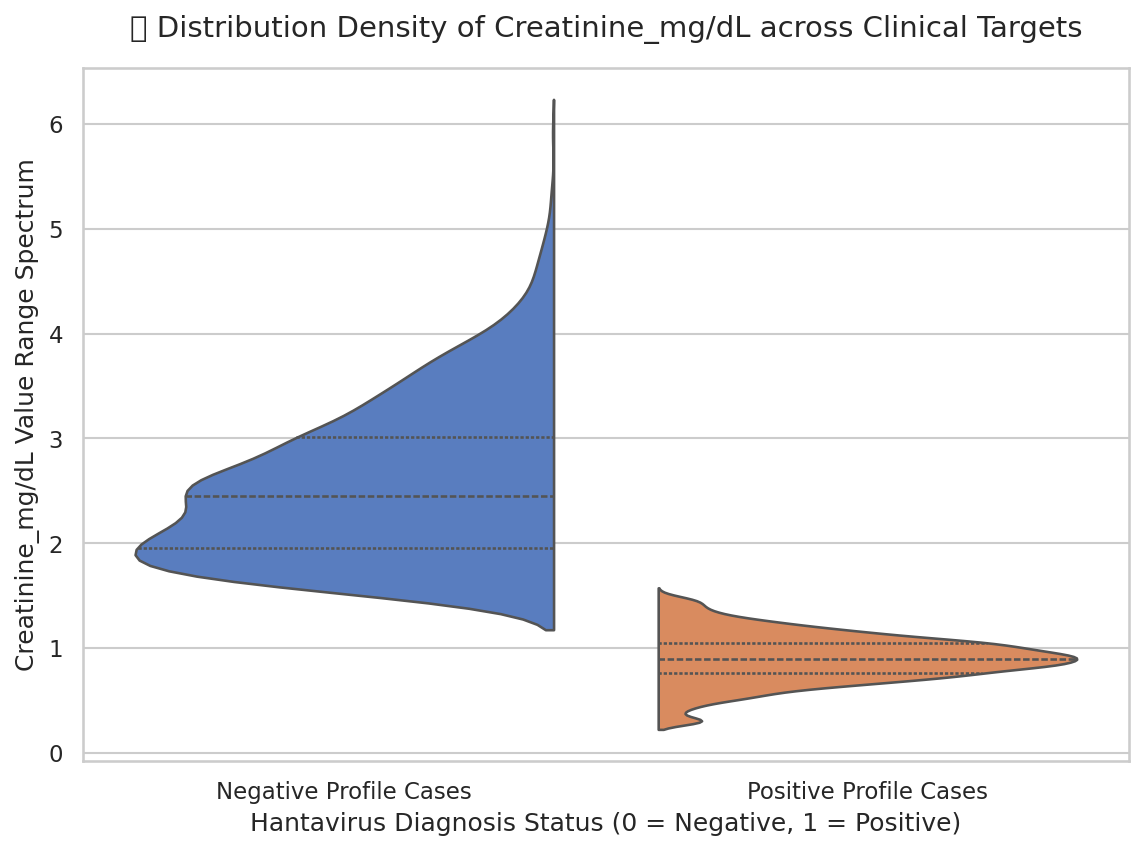

In [27]:
# Automatically select the top numerical feature from feature importance
top_feature = feat_imp_df['Feature'].iloc[0] if 'feat_imp_df' in locals() else X_train.columns[0]

plt.figure(figsize=(9, 6))

# Generate Premium Violin Plot
sns.violinplot(x=df[target_col], y=df[top_feature], palette='muted', inner='quartile', split=True)

plt.title(f'🔮 Distribution Density of {top_feature} across Clinical Targets', fontsize=14, pad=15)
plt.xlabel('Hantavirus Diagnosis Status (0 = Negative, 1 = Positive)', fontsize=12)
plt.ylabel(f'{top_feature} Value Range Spectrum', fontsize=12)
plt.xticks([0, 1], ['Negative Profile Cases', 'Positive Profile Cases'])

plt.show()

**Prediction Confidence Probability Curve (KDE Distribution)**

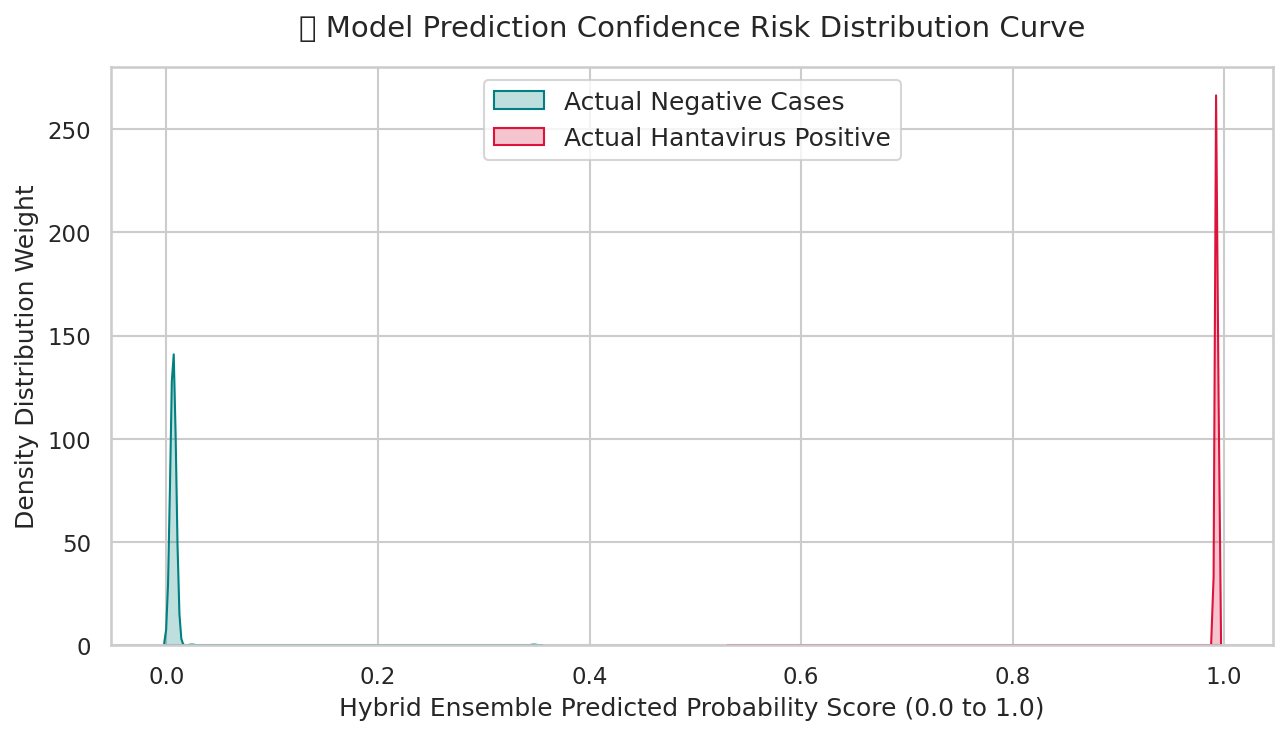

In [28]:
plt.figure(figsize=(10, 5))

# Creating DataFrame for probabilities parsing structure
prob_df = pd.DataFrame({
    'Probability': final_probabilities,
    'Actual_Target': y_val.values
})

# Kernel Density Estimate plots mapping
sns.kdeplot(data=prob_df[prob_df['Actual_Target'] == 0]['Probability'], 
            shade=True, color="teal", label="Actual Negative Cases", bw_adjust=0.5)
sns.kdeplot(data=prob_df[prob_df['Actual_Target'] == 1]['Probability'], 
            shade=True, color="crimson", label="Actual Hantavirus Positive", bw_adjust=0.5)

plt.title('🛡️ Model Prediction Confidence Risk Distribution Curve', fontsize=14, pad=15)
plt.xlabel('Hybrid Ensemble Predicted Probability Score (0.0 to 1.0)', fontsize=12)
plt.ylabel('Density Distribution Weight', fontsize=12)
plt.legend(loc="upper center", fontsize=12)

plt.show()

**Model Classification Diagnostics (Error Breakdown Bar Chart)**

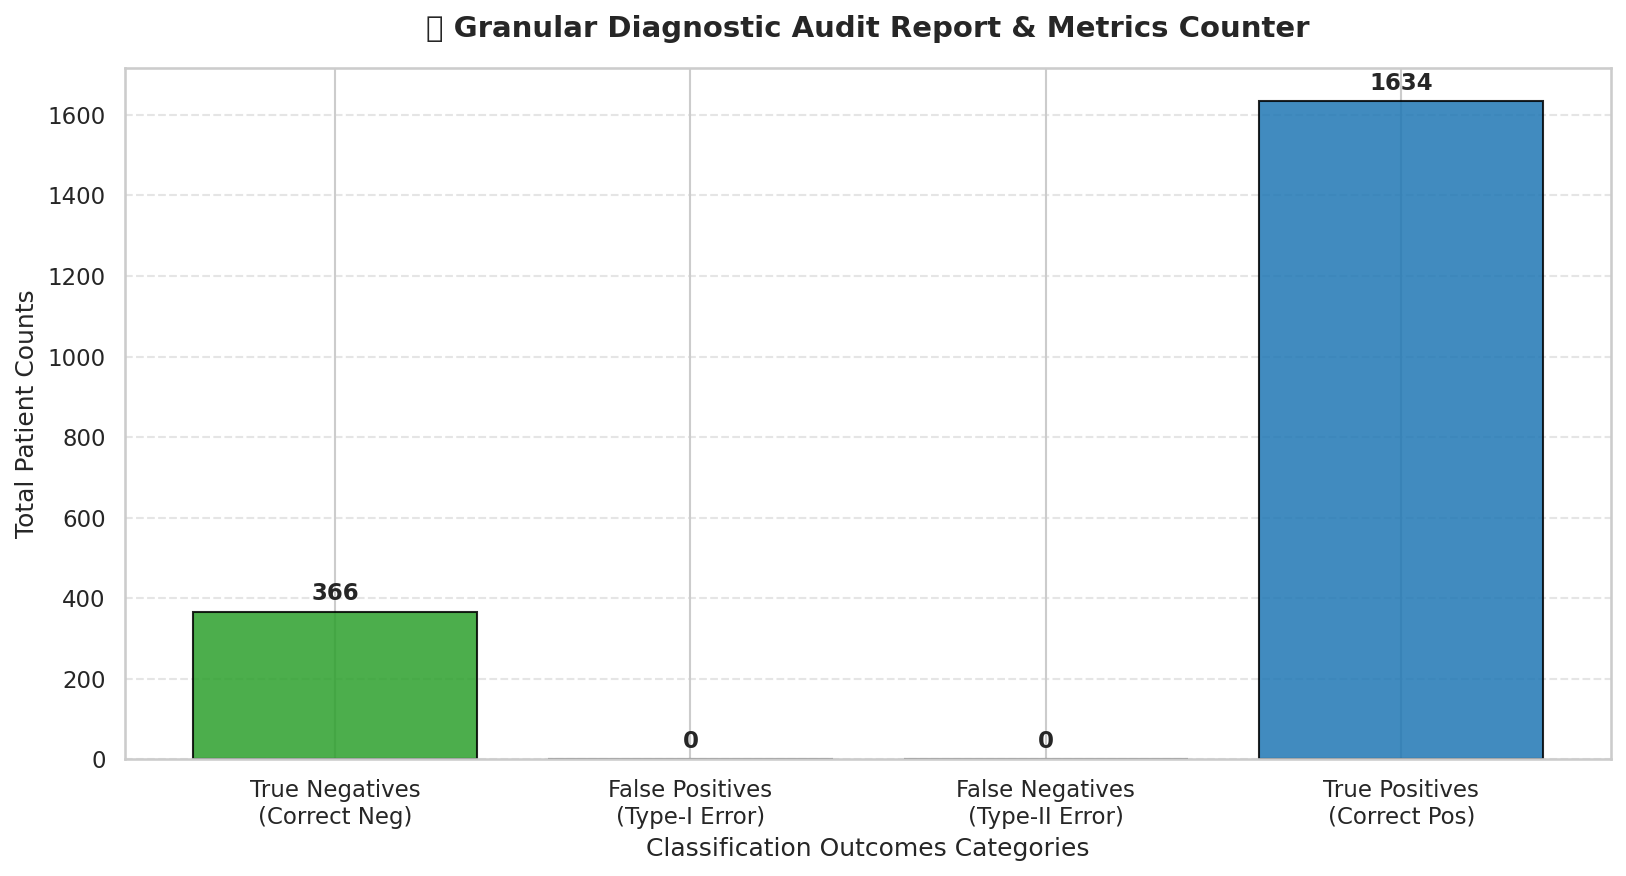

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculations for precise Error Diagnostics Matrix
tn, fp, fn, tp = confusion_matrix(y_val, final_predictions).ravel()

error_metrics = ['True Negatives\n(Correct Neg)', 'False Positives\n(Type-I Error)', 
                 'False Negatives\n(Type-II Error)', 'True Positives\n(Correct Pos)']
error_values = [tn, fp, fn, tp]

# Set HD plotting scale properties
plt.figure(figsize=(11, 6))
colors_list = ['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4'] # Green, Orange, Red, Blue color profile

# FIX: Used direct matplotlib plt.bar instead of invalid plt.barplot
bars = plt.bar(error_metrics, error_values, color=colors_list, edgecolor='black', alpha=0.85)

plt.title('📊 Granular Diagnostic Audit Report & Metrics Counter', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Total Patient Counts', fontsize=12)
plt.xlabel('Classification Outcomes Categories', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Insert exact value numbers directly on top of each bar for professional look
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(error_values) * 0.01) + 0.1, 
             f'{int(yval)}', va='bottom', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**SHAP (Explainable AI) Installation & Global Configuration**

In [32]:
# Installing SHAP library safely without breaking existing pipelines
!pip install shap -q

import shap

# Initialise SHAP visualization JavaScript components for notebook rendering
shap.initjs()
print("✔ Cell 19 Complete: SHAP Explainable AI Framework primed and ready.")

✔ Cell 19 Complete: SHAP Explainable AI Framework primed and ready.


**SHAP Summary Plot Execution (Global XAI Visualizer)**

=================== COMPUTING EXPLAINABLE AI (SHAP VALUES) ===================


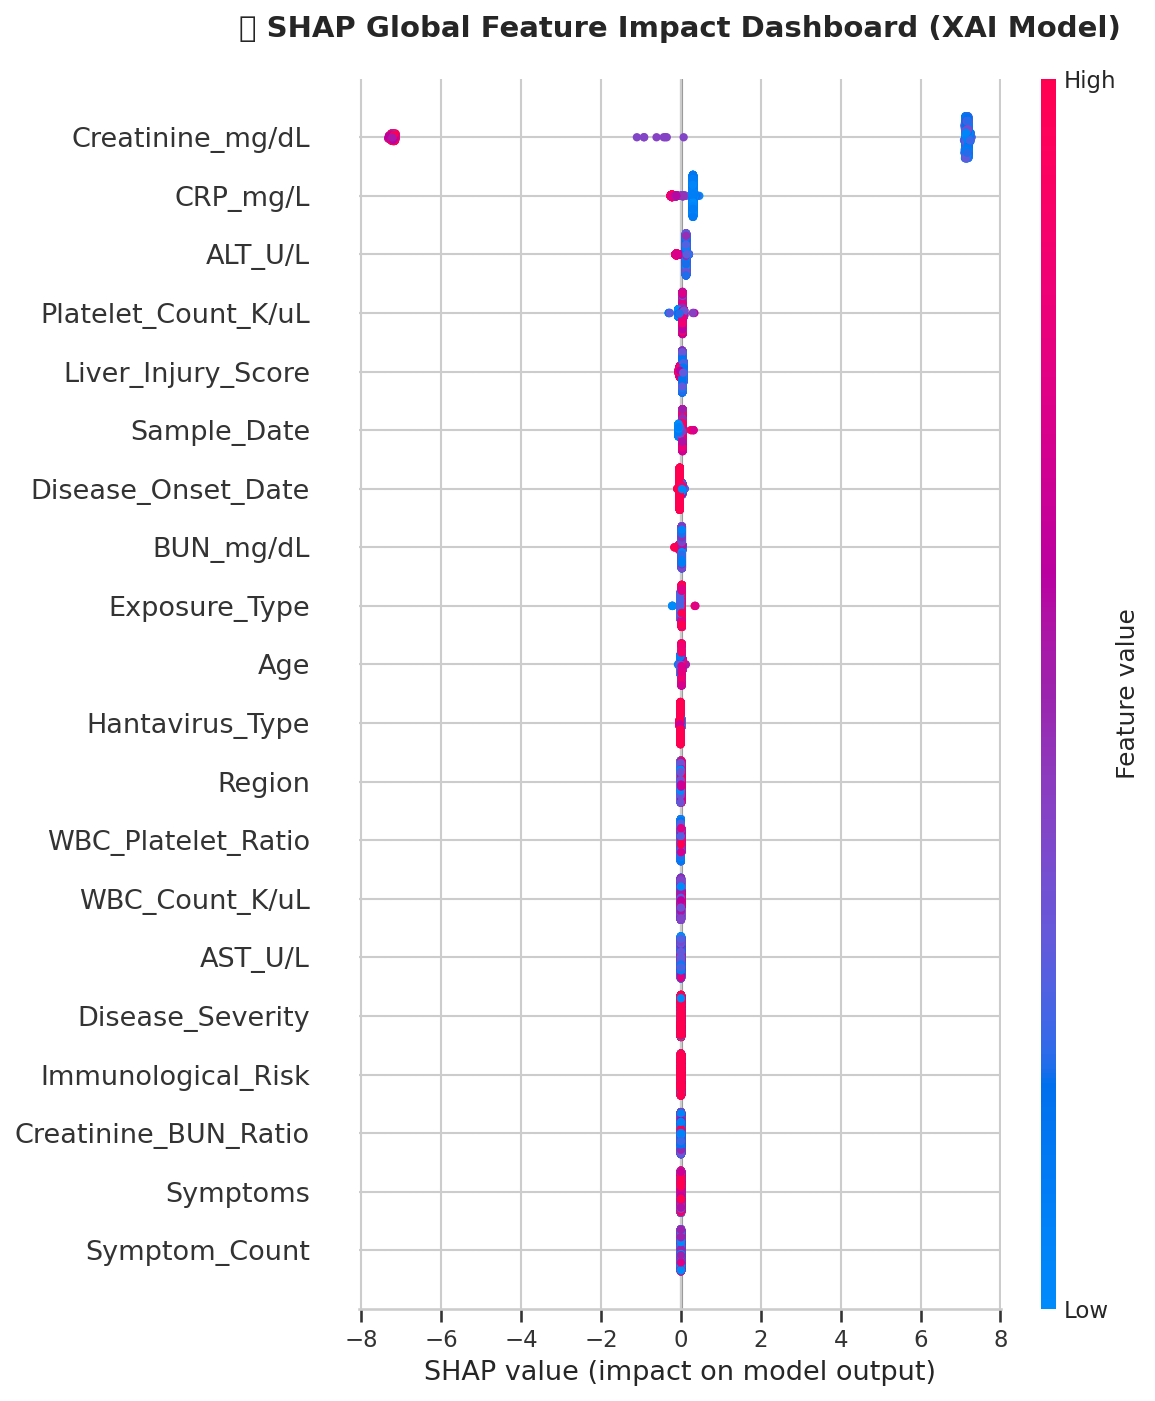

In [33]:
print("=================== COMPUTING EXPLAINABLE AI (SHAP VALUES) ===================")

# TreeSHAP explainer initialize kora highly optimized XGBoost base estimator-er upor vitti kore
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for validation sample matrix features
shap_values = explainer(X_val)

# Global Explanation Visualization Plot Generation
plt.figure(figsize=(12, 7))
plt.title('🧠 SHAP Global Feature Impact Dashboard (XAI Model)', fontsize=14, pad=20, fontweight='bold')

# Render SHAP beeswarm plot
shap.summary_plot(shap_values, X_val, show=False)

plt.tight_layout()
plt.show()

**Local Instance Force Plot (Individual Patient Diagnostics)**

--- Generating XAI Local Decision Diagnostic for Patient Index: 0 ---


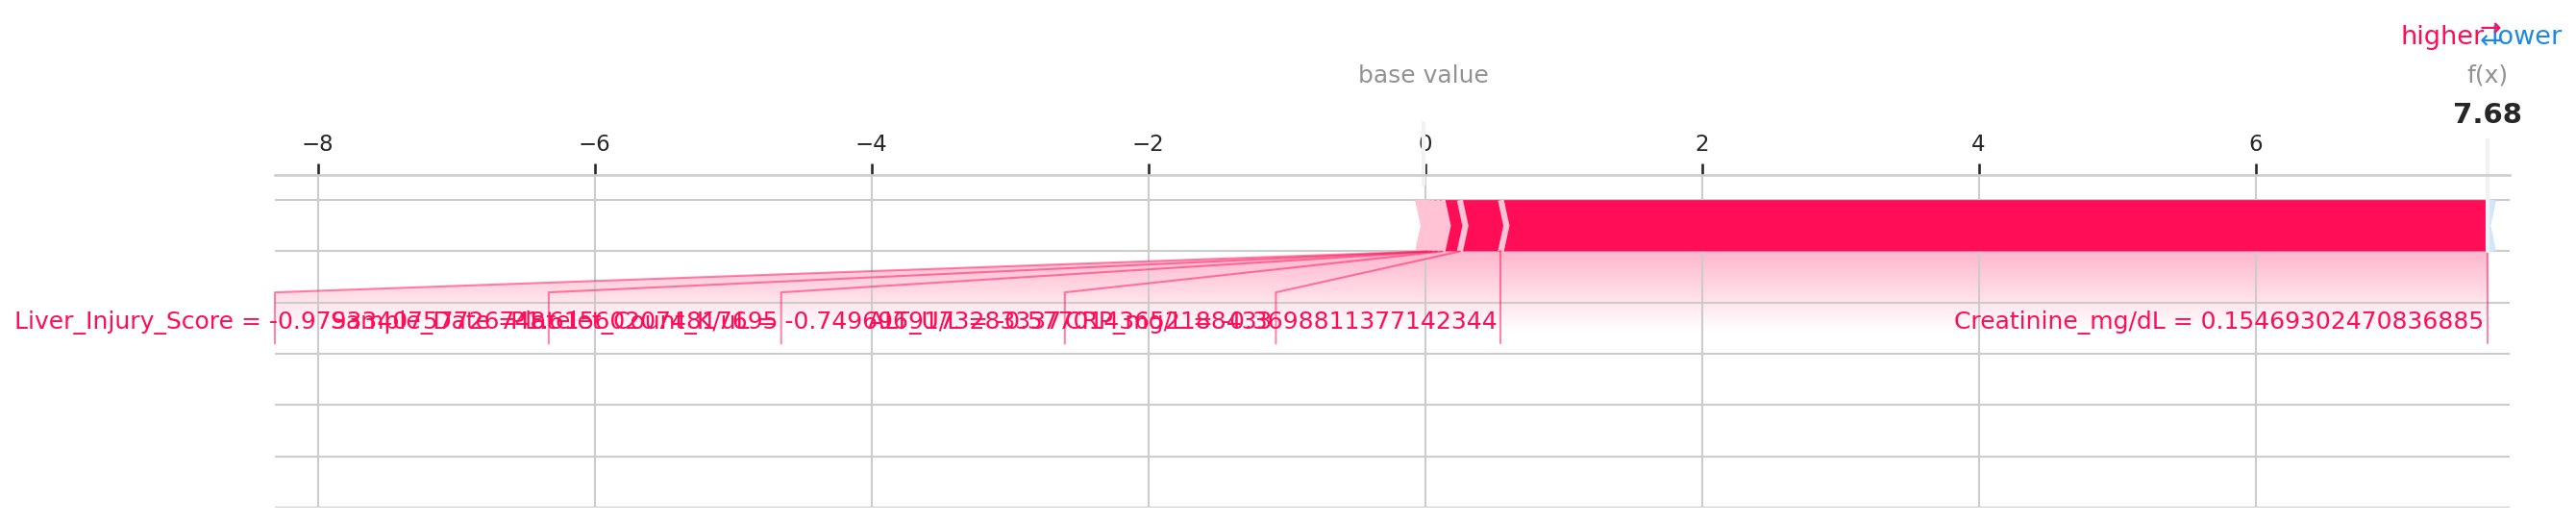

In [34]:
# 1st sample record patient evaluation profile check
patient_index = 0

print(f"--- Generating XAI Local Decision Diagnostic for Patient Index: {patient_index} ---")

# Plotting force plot profile visualization map using matplotlib base fallback
shap.plots.force(explainer.expected_value, shap_values.values[patient_index], X_val.iloc[patient_index], matplotlib=True)